## Worked example of GWR (Python)

This notebook mirrors the structure and analyses from `tutorial_GWR.Rmd`, translating them into Python with GeoPandas, Statsmodels, scikit-gstat, and MGWR.

### Goal
- Estimate spatially varying relationships (GWR) of corn yield to N and seeding rates.
- Use the tidied spatial dataset stored as a GeoPackage.

### Dataset
- GeoPackage: `Field05.gpkg`
- Path: `/Users/emine2/Documents/CLASSES/01_2024-FALL/CPSC-444_SpatialAnalysis/Module_4-5/Module 4.5 Data & Slides/GWR Case study/Field05.gpkg`

### Requirements
Install packages if needed (uncomment and run in a terminal or a notebook cell):
```bash
pip install geopandas pyproj shapely rtree statsmodels seaborn matplotlib pandas numpy scikit-gstat mgwr contextily
```



In [ ]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install scikit-gstat mgwr

In [3]:
# Imports and setup
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

# Stats / models
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Variogram
from skgstat import Variogram

# GWR
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW

# Mapping
import contextily as cx

# Plot style
sns.set(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (8, 6), "figure.dpi": 120})

# Paths
BASE_DIR = "/Users/emine2/Documents/CLASSES/01_2024-FALL/CPSC-444_SpatialAnalysis/Module_4-5/Module 4.5 Data & Slides/GWR Case study"
GPKG_PATH = os.path.join(BASE_DIR, "Field05.gpkg")

print("GeoPackage path exists:", os.path.exists(GPKG_PATH))


GeoPackage path exists: True


In [4]:
field05 = gpd.read_file('/Users/emine2/Documents/CLASSES/01_2024-FALL/CPSC-444_SpatialAnalysis/Module_4-5/Module 4.5 Data & Slides/GWR Case study/Field05.gpkg')

In [5]:
# Ensure SRPlanf and NPlanf are categorical (Option A)
from pandas.api.types import is_categorical_dtype

if 'SRPlanf' not in field05.columns:
    field05['SRPlanf'] = field05['SRPlan']
if not is_categorical_dtype(field05['SRPlanf']):
    field05['SRPlanf'] = field05['SRPlanf'].astype('category')

if 'NPlanf' not in field05.columns:
    field05['NPlanf'] = field05['NPlan']
if not is_categorical_dtype(field05['NPlanf']):
    field05['NPlanf'] = field05['NPlanf'].astype('category')

print('SRPlanf dtype:', field05['SRPlanf'].dtype)
print('NPlanf dtype:', field05['NPlanf'].dtype)


SRPlanf dtype: category
NPlanf dtype: category


In [ ]:
# Load data and basic inspection
# Read GeoPackage into a GeoDataFrame
field05 = gpd.read_file(GPKG_PATH)
field05 = field05.to_crs(epsg=32616)  # match projection 

# Quick look at structure
display(field05.head())
print("CRS:", field05.crs)
print("Rows, Columns:", field05.shape)

# List columns of interest
cols_interest = [
    "SubID","ID","SRPlan","NPlan","Area","Headland","N_pts","MuKey",
    "ECS","ECS_sd","ECD","ECD_sd","Elev","Elev_sd","Slope","Slope_sd",
    "Curv","Curv_sd","TWI","TWI_sd","TPI","TPI_sd","Yield","Yield_sd",
    "Moisture","Moisture_sd","VI1","VI1_sd","VI2","VI2_sd","VI3","VI3_sd",
    "SRPlan2","NRPlan2","SRPlanf","NPlanf"
]
print("Available columns:", [c for c in cols_interest if c in field05.columns])


,SubID,ID,SRPlan,NPlan,Area,Headland,N_pts,MuKey,ECS_sd,ECS,...,VI1,VI2_sd,VI2,VI3_sd,VI3,SRPlan2,NPlan2,NPlanf,SRPlanf,geometry
0,39,24,31000.0,44.0,1560.298728,No,16,246517,0.546958,20.442388,...,-0.025056,0.005544,-0.078950,0.008520,-0.004986,9.610000e+08,1936.0,44,31k,"POLYGON ((364080.179 4398372.820, 364101.508 4..."
1,40,24,31000.0,44.0,1560.298728,No,15,246517,0.772253,22.111250,...,-0.009737,0.007371,-0.084663,0.006777,0.004405,9.610000e+08,1936.0,44,31k,"POLYGON ((364101.509 4398372.447, 364122.838 4..."
2,41,25,34500.0,38.0,1560.297979,No,15,246544,0.718886,23.301075,...,-0.014970,0.008884,-0.097565,0.005224,-0.001865,1.190250e+09,1444.0,38,34k,"POLYGON ((364122.838 4398372.074, 364144.167 4..."
3,42,25,34500.0,38.0,1560.297979,No,16,246544,0.755857,22.708853,...,-0.039440,0.017035,-0.081638,0.003575,0.003028,1.190250e+09,1444.0,38,34k,"POLYGON ((364144.168 4398371.701, 364165.497 4..."
4,43,25,34500.0,38.0,1560.297979,No,14,246544,0.322303,21.599925,...,-0.098559,0.018276,-0.026506,0.012072,-0.006675,1.190250e+09,1444.0,38,34k,"POLYGON ((364165.497 4398371.328, 364186.826 4..."


CRS: EPSG:32616
Rows, Columns: (832, 41)
Available columns: ['SubID', 'ID', 'SRPlan', 'NPlan', 'Area', 'Headland', 'N_pts', 'MuKey', 'ECS', 'ECS_sd', 'ECD', 'ECD_sd', 'Elev', 'Elev_sd', 'Slope', 'Slope_sd', 'Curv', 'Curv_sd', 'TWI', 'TWI_sd', 'TPI', 'TPI_sd', 'Yield', 'Yield_sd', 'Moisture', 'Moisture_sd', 'VI1', 'VI1_sd', 'VI2', 'VI2_sd', 'VI3', 'VI3_sd', 'SRPlan2', 'SRPlanf', 'NPlanf']


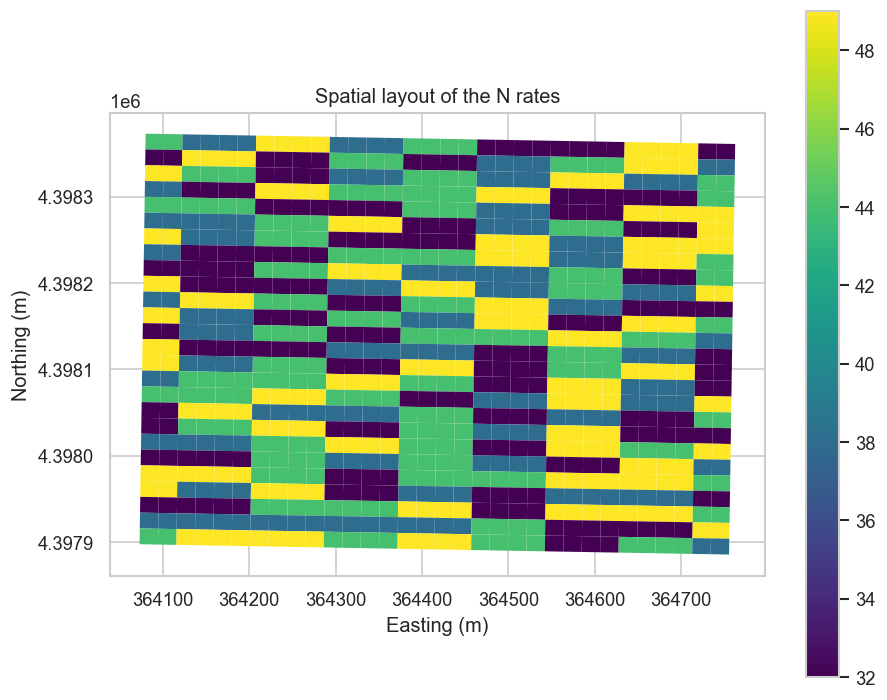

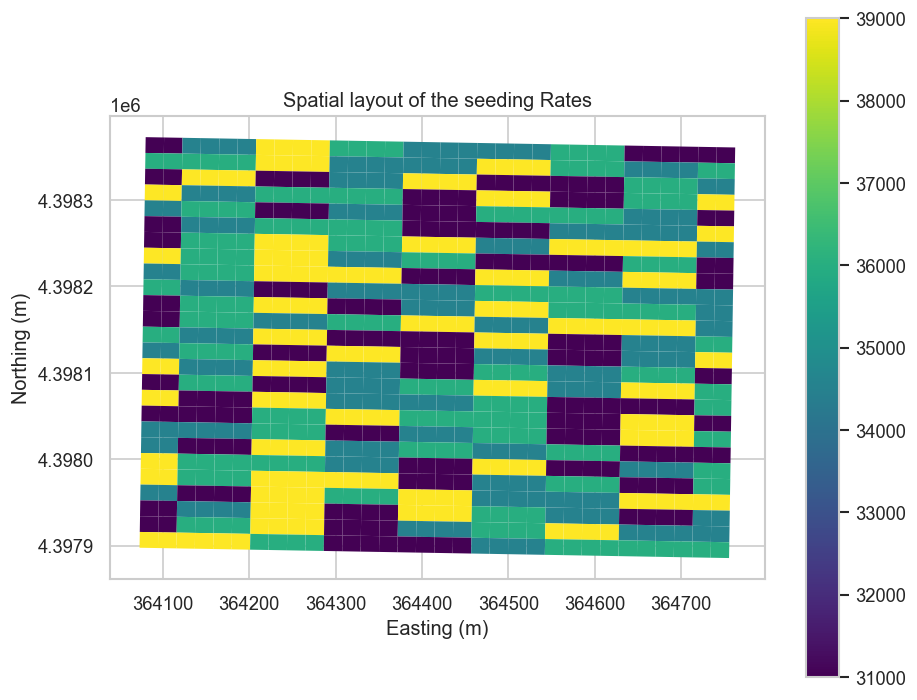

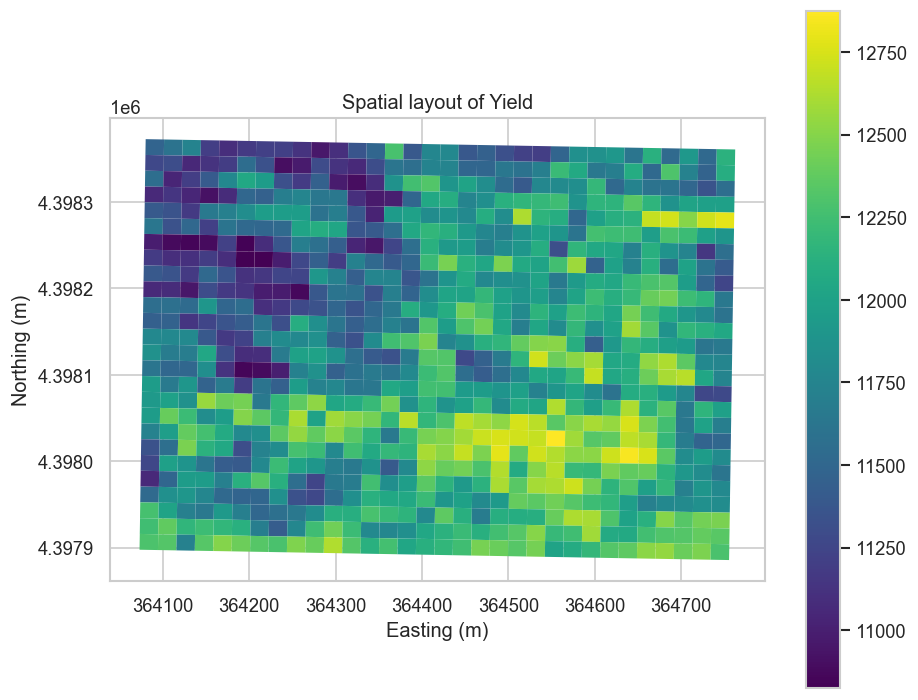

In [7]:
# Spatial layout maps (NPlan, SRPlan, Yield)
# Helper to plot a choropleth with consistent style

def plot_choropleth(gdf, column, title, cmap="viridis"):
    ax = gdf.plot(column=column, cmap=cmap, edgecolor="none", legend=True)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.tight_layout()
    plt.show()

plot_choropleth(field05, "NPlan", "Spatial layout of the N rates")
plot_choropleth(field05, "SRPlan", "Spatial layout of the seeding Rates")
plot_choropleth(field05, "Yield", "Spatial layout of Yield")


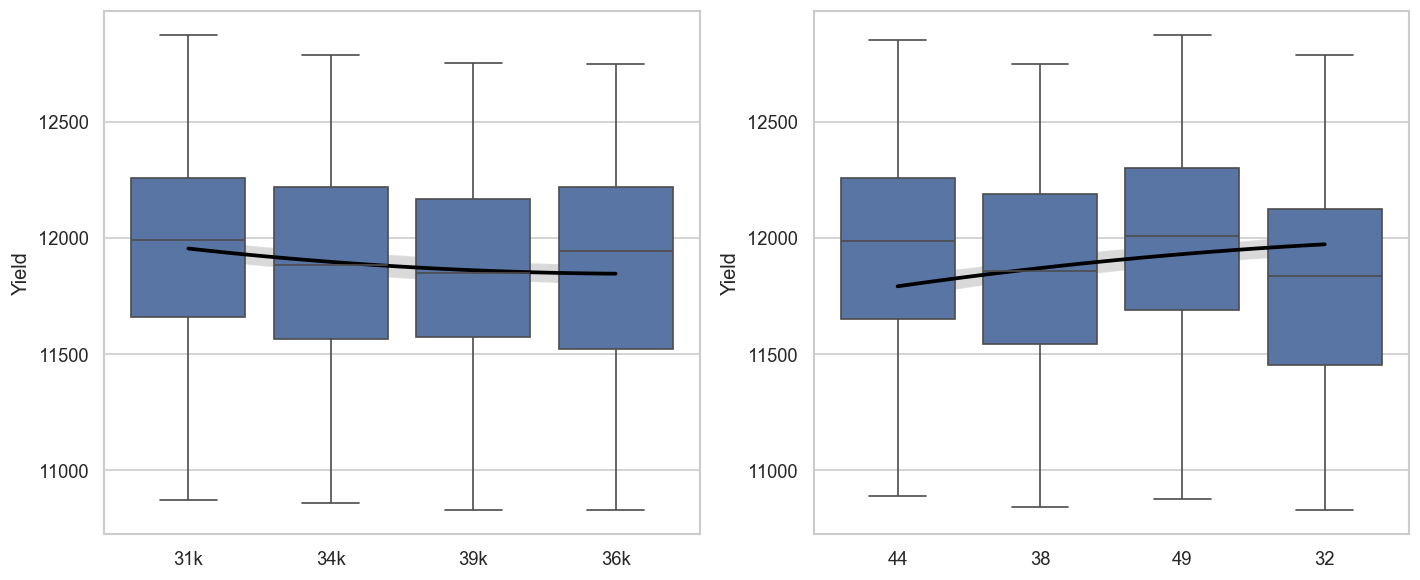

In [8]:
# Boxplots: Yield vs SRPlanf and Yield vs NPlanf
# Ensure factors exist or derive them from numeric bins if needed
if "SRPlanf" not in field05.columns:
    field05["SRPlanf"] = field05["SRPlan"].astype("category")
if "NPlanf" not in field05.columns:
    field05["NPlanf"] = field05["NPlan"].astype("category")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=field05, x="SRPlanf", y="Yield", ax=axes[0])
axes[0].set_xlabel("seeding Rate (seed/ac)")
axes[0].set_ylabel("Yield (kg/ha)")
sns.regplot(x=field05['SRPlanf'].astype('category').cat.codes, y=field05['Yield'], order=2, scatter=False, ax=axes[0], color='black')


sns.boxplot(data=field05, x="NPlanf", y="Yield", ax=axes[1])
axes[1].set_xlabel("N Rate (kg/ha)")
axes[1].set_ylabel("Yield (kg/ha)")
sns.regplot(x=field05['NPlanf'].astype('category').cat.codes, y=field05['Yield'], order=2, scatter=False, ax=axes[1], color='black')
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                  Yield   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     10.60
Date:                Thu, 16 Oct 2025   Prob (F-statistic):           7.63e-07
Time:                        09:50:22   Log-Likelihood:                -6237.9
No. Observations:                 832   AIC:                         1.248e+04
Df Residuals:                     828   BIC:                         1.250e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     9492.8423   1239.842      7.656   

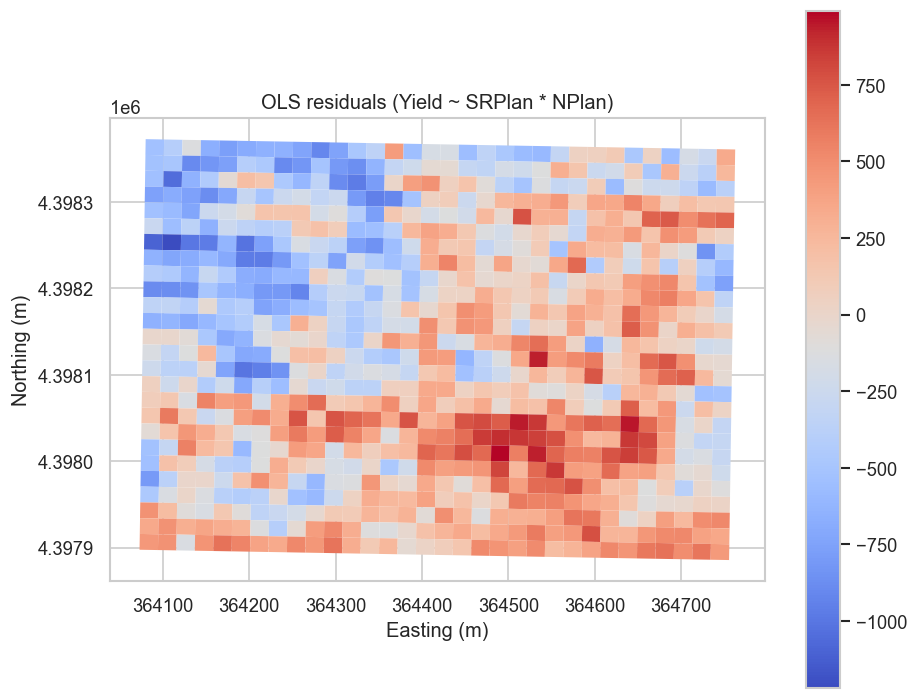

In [9]:
# Basic linear model: Yield ~ SRPlan * NPlan
# Fit using statsmodels formula API, add residuals to GeoDataFrame
m_lm = ols("Yield ~ SRPlan * NPlan", data=field05).fit()
print(m_lm.summary())

field05["resid"] = m_lm.resid

# Plot residuals choropleth
plot_choropleth(field05, "resid", "OLS residuals (Yield ~ SRPlan * NPlan)", cmap="coolwarm")


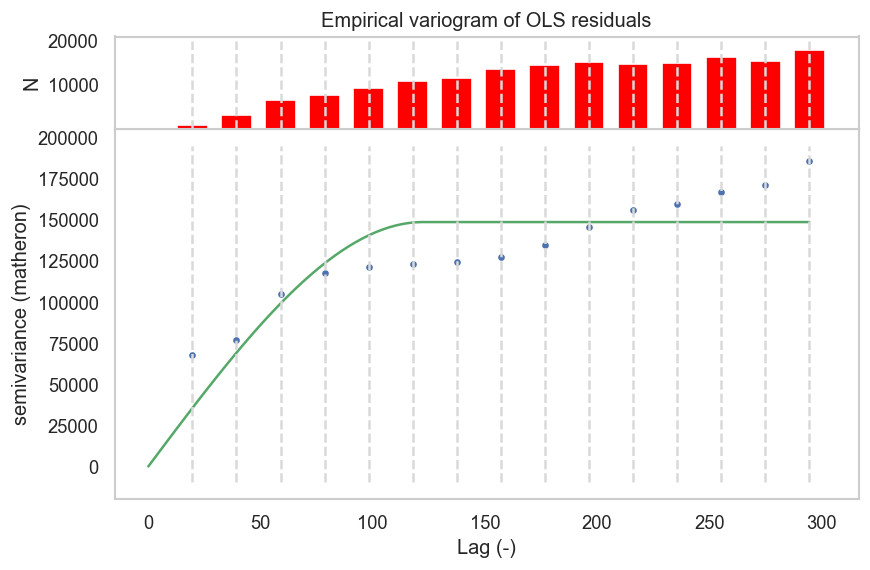

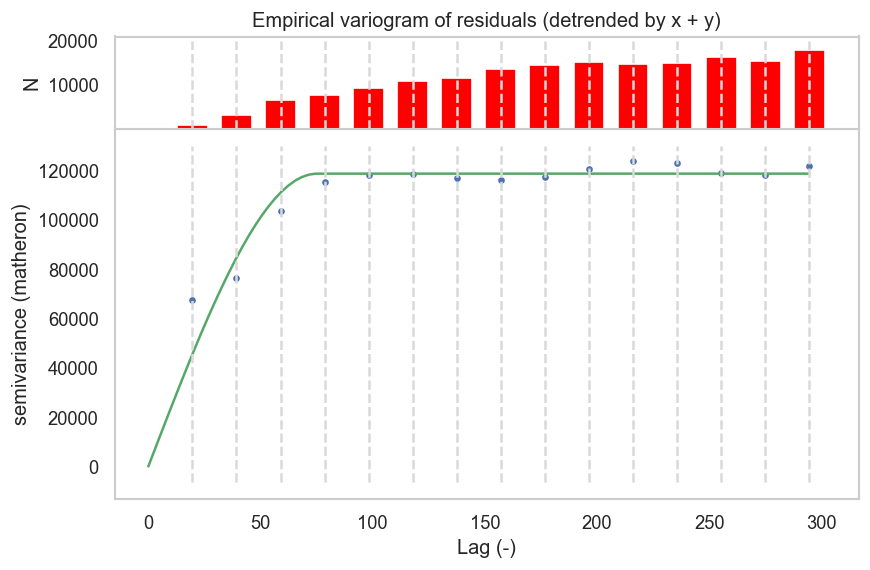

Trend R^2: 0.3641125837148351


In [10]:
# Variogram of residuals and detrended variogram
# Extract point centroids for polygons for variogram calculations
centroids = field05.geometry.centroid
coords = np.vstack([centroids.x.values, centroids.y.values]).T
residuals = field05["resid"].values

# Empirical variogram
V = Variogram(coords, residuals, normalize=False, n_lags=15, maxlag="median")
fig = V.plot()
plt.title("Empirical variogram of OLS residuals")
plt.show()

# Detrending using linear coordinates (x, y)
X_trend = sm.add_constant(pd.DataFrame({"x": coords[:,0], "y": coords[:,1]}))
trend_model = sm.OLS(residuals, X_trend).fit()
resid_detrended = residuals - trend_model.predict(X_trend)

V_detrended = Variogram(coords, resid_detrended, normalize=False, n_lags=15, maxlag="median")
fig = V_detrended.plot()
plt.title("Empirical variogram of residuals (detrended by x + y)")
plt.show()

print("Trend R^2:", trend_model.rsquared)


Selected bandwidth (adaptive): 48.0
Model type                                                         Gaussian
Number of observations:                                                 832
Number of covariates:                                                     2

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                       163045586.407
Log-likelihood:                                                   -6249.811
AIC:                                                              12503.623
AICc:                                                             12505.652
BIC:                                                           163040005.626
R2:                                                                   0.009
Adj. R2:                                                              0.008

Variable                              Est.         SE  t(Est/SE)    p-value
----------------------

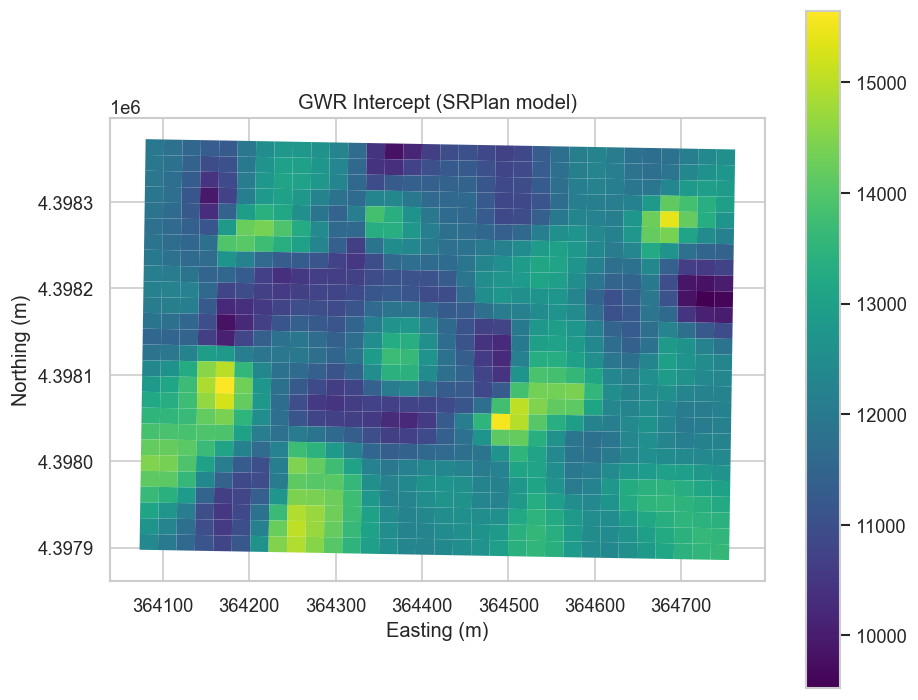

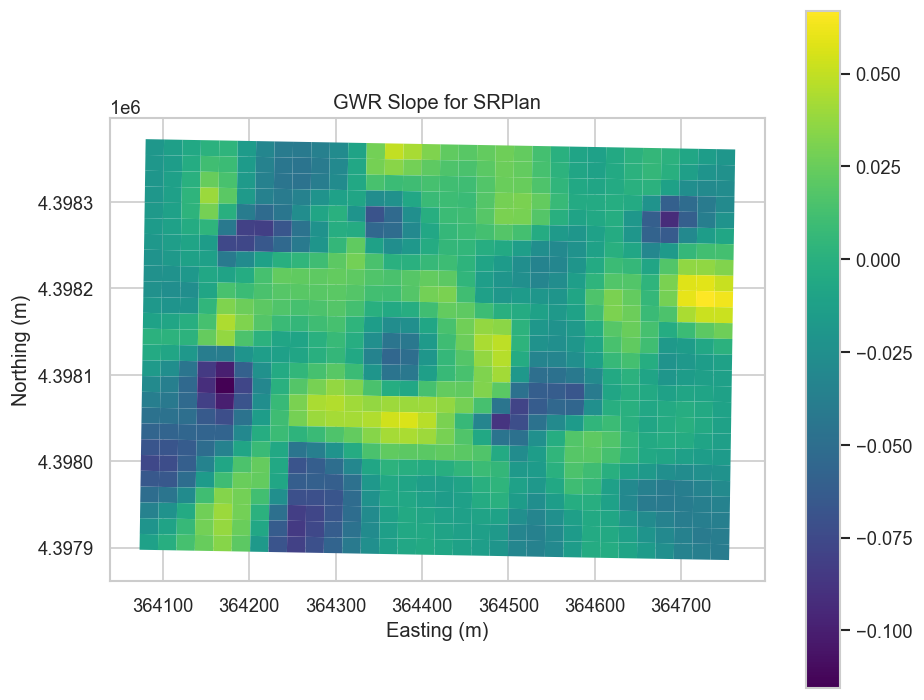

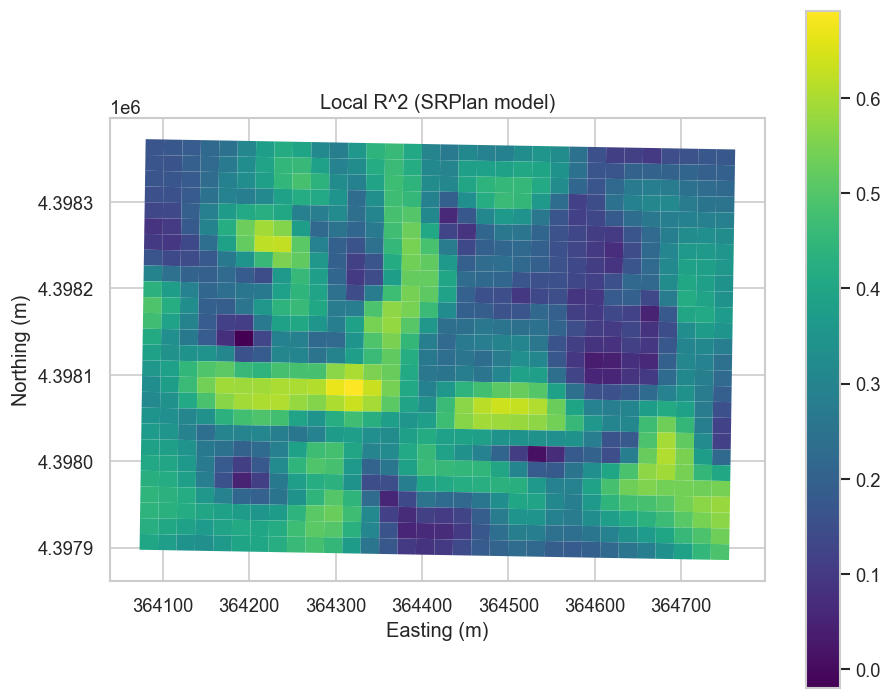

In [12]:
# GWR: Yield ~ SRPlan (adaptive bandwidth)
# Prepare coordinates (u, v) and design matrix
centroids = field05.geometry.centroid
u = centroids.x.values.reshape((-1, 1))
v = centroids.y.values.reshape((-1, 1))
coords_gwr = np.hstack([u, v])

# Response and predictor
y = field05[["Yield"]].values
X = field05[["SRPlan"]].values
X = sm.add_constant(X, has_constant='add')

# Bandwidth selection (adaptive)
#bw = Sel_BW(coords_gwr, y, X, spherical=False).search(adaptive=True)
selector = Sel_BW(coords_gwr, y, X, fixed=False, spherical=False)  # adaptive kNN
bw = selector.search()
print("Selected bandwidth (adaptive):", bw)

# Fit GWR
model = GWR(coords_gwr, y, X, bw=bw, fixed=False).fit()
print(model.summary())

# Collect results
coef_names = ["Intercept", "SRPlan"]
coef_df = pd.DataFrame(model.params, columns=coef_names)
coef_df["localR2"] = model.localR2

# Merge back to GeoDataFrame (spatial join by index)
res_SRlin = field05.copy()
for col in coef_df.columns:
    res_SRlin[col] = coef_df[col].values

# Plot coefficients and localR2
plot_choropleth(res_SRlin, "Intercept", "GWR Intercept (SRPlan model)")
plot_choropleth(res_SRlin, "SRPlan", "GWR Slope for SRPlan")
plot_choropleth(res_SRlin, "localR2", "Local R^2 (SRPlan model)")


/Users/emine2/Library/Python/3.9/lib/python/site-packages/spglm/iwls.py:37: LinAlgWarning: Ill-conditioned matrix (rcond=4.36662e-17): result may not be accurate.
  xtx_inv_xt = linalg.solve(xtx, xT)
/Users/emine2/Library/Python/3.9/lib/python/site-packages/spglm/iwls.py:37: LinAlgWarning: Ill-conditioned matrix (rcond=4.53854e-17): result may not be accurate.
  xtx_inv_xt = linalg.solve(xtx, xT)
/Users/emine2/Library/Python/3.9/lib/python/site-packages/spglm/iwls.py:37: LinAlgWarning: Ill-conditioned matrix (rcond=4.59482e-17): result may not be accurate.
  xtx_inv_xt = linalg.solve(xtx, xT)
/Users/emine2/Library/Python/3.9/lib/python/site-packages/spglm/iwls.py:37: LinAlgWarning: Ill-conditioned matrix (rcond=4.6532e-17): result may not be accurate.
  xtx_inv_xt = linalg.solve(xtx, xT)
/Users/emine2/Library/Python/3.9/lib/python/site-packages/spglm/iwls.py:37: LinAlgWarning: Ill-conditioned matrix (rcond=4.70618e-17): result may not be accurate.
  xtx_inv_xt = linalg.solve(xtx, xT)
/

Selected bandwidth (adaptive kNN): 49.0
Model type                                                         Gaussian
Number of observations:                                                 832
Number of covariates:                                                     6

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                       132735569.781
Log-likelihood:                                                   -6164.252
AIC:                                                              12340.505
AICc:                                                             12342.640
BIC:                                                           132730015.896
R2:                                                                   0.193
Adj. R2:                                                              0.188

Variable                              Est.         SE  t(Est/SE)    p-value
------------------

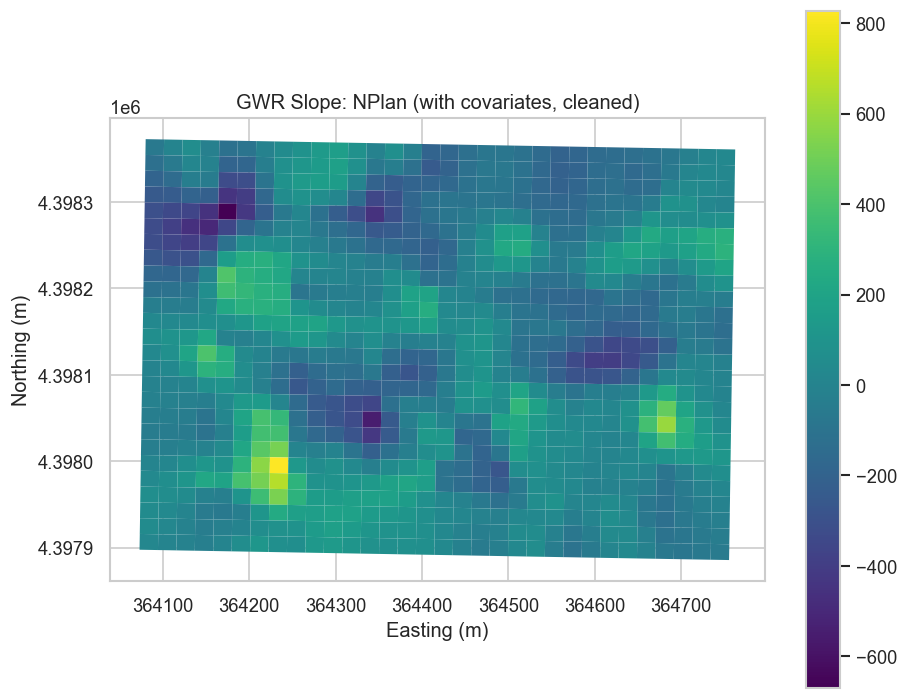

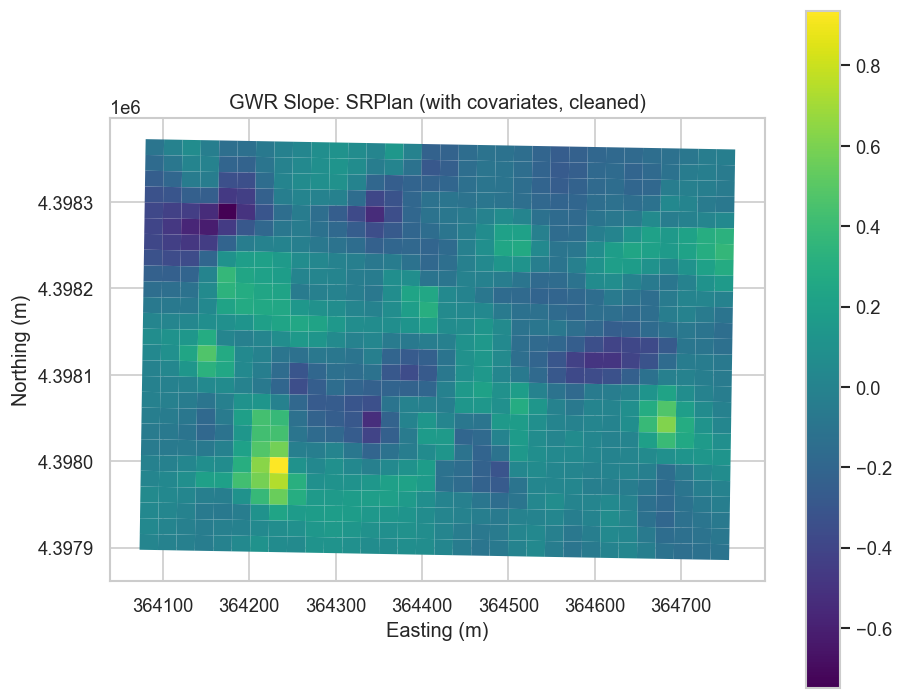

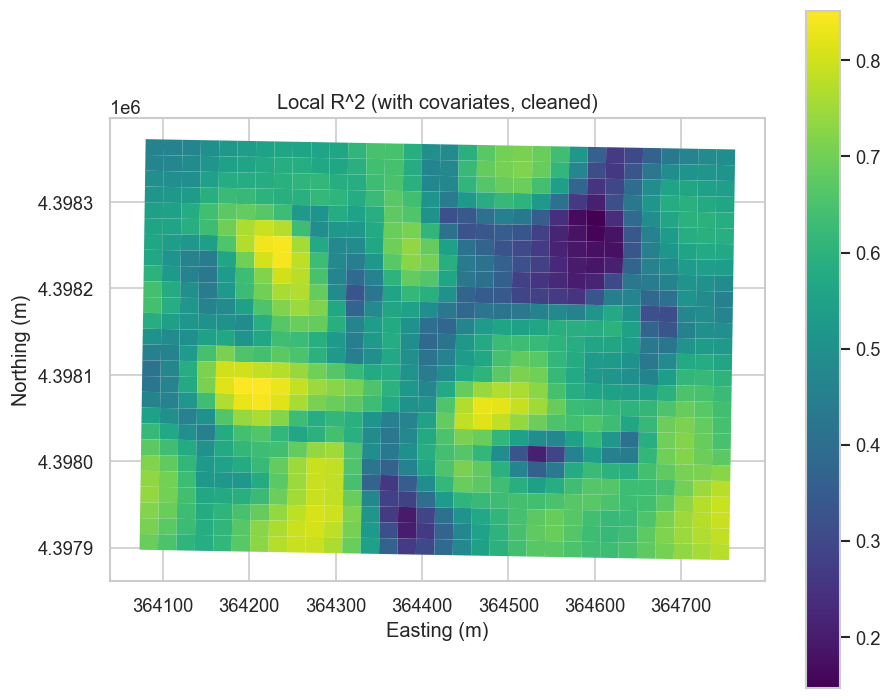

In [13]:
X_design = field05[['NPlan', 'SRPlan', 'ECD', 'MuKey']].copy()
X_design['MuKey'] = pd.to_numeric(X_design['MuKey'], errors='coerce')
X_design['NPlan_SRPlan'] = X_design['NPlan'] * X_design['SRPlan']  # interaction
# Do NOT add a constant; GWR adds intercept by default (constant=True)

# Coerce to float and drop rows with NaNs
X_numeric = X_design.apply(pd.to_numeric, errors='coerce')
y_series = pd.to_numeric(field05['Yield'], errors='coerce')
mask = (~X_numeric.isna().any(axis=1)) & (~y_series.isna())

X_arr = X_numeric.loc[mask].to_numpy(dtype=float)
y_arr = y_series.loc[mask].to_numpy(dtype=float).reshape(-1, 1)
coords_mask = coords_gwr[mask.values, :]

# Bandwidth selection (adaptive kNN) with safe lower bound
p = X_arr.shape[1]  # number of predictors (no intercept here)
selector = Sel_BW(coords_mask, y_arr, X_arr, fixed=False, spherical=False)
bw = selector.search(bw_min=max(2 * p + 1, 40))
print("Selected bandwidth (adaptive kNN):", bw)

# Fit GWR (intercept added internally)
model = GWR(coords_mask, y_arr, X_arr, bw=bw, fixed=False).fit()
print(model.summary())

# Collect results
col_order = list(X_numeric.columns)  # in order: NPlan, SRPlan, ECD, MuKey, NPlan_SRPlan
coef_df = pd.DataFrame(model.params, columns=['Intercept'] + col_order)
coef_df['localR2'] = model.localR2

# Merge back to filtered GeoDataFrame
res_cov = field05.loc[mask].copy()
for col in coef_df.columns:
    res_cov[col] = coef_df[col].values

# Plot key outputs
plot_choropleth(res_cov, 'NPlan', 'GWR Slope: NPlan (with covariates, cleaned)')
plot_choropleth(res_cov, 'SRPlan', 'GWR Slope: SRPlan (with covariates, cleaned)')
plot_choropleth(res_cov, 'localR2', 'Local R^2 (with covariates, cleaned)')

## Summary

- The GWR procedure estimates spatially varying relationships between Yield and explanatory variables.
- We replicated the R workflow using Python libraries: GeoPandas (data), Statsmodels (OLS), scikit-gstat (variogram), and MGWR (GWR).
- We mapped coefficients and local R^2 for models using SRPlan, NPlan, their interaction, and additional covariates (MuKey, ECD).

Notes:
- Depending on your environment, you may need to install `rtree` for spatial indexing and ensure GEOS/GDAL/PROJ are available.
- If plots render slowly, consider simplifying geometries or plotting centroids for choropleths.
